In [2]:
import yfinance as yf
import pandas as pd
import datetime as dt
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Create data directory
folder_name = "data"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")

# Quantamental Universe ETFs
tickers = ["SPY", "QQQ", "IWM", "VWO", "GLD", "SHV", "IEF", "TLT", "TIP", "LQD"]

# 20-Year timeframe
end_date = dt.date.today()
start_date = end_date - dt.timedelta(days=20*365)

print(f"Downloading data from {start_date} to {end_date}...")

# Download data
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
prices_adj = raw_data['Adj Close'].copy()

# Inception Date Report
print("--- ETF Inception Dates Report ---")
for etf in tickers:
    first_valid = prices_adj[etf].first_valid_index()
    if first_valid is not None:
        print(f"[{etf}] Active since: {first_valid.date()}")
    else:
        print(f"[{etf}] No data found.")

# Data Cleaning: Forward Fill for market holidays
prices_adj = prices_adj.ffill()

# Save to Excel
file_path = os.path.join(folder_name, "Prezzi_Reali_20Y.xlsx")
prices_adj.to_excel(file_path)
print(f"\nDownload complete. File saved at: {file_path}")

Folder 'data' already exists.


[*********************100%***********************]  10 of 10 completed


--- ETF Inception Dates Report ---
[SPY] Active since: 2006-07-03
[QQQ] Active since: 2006-07-03
[IWM] Active since: 2006-07-03
[VWO] Active since: 2006-07-03
[GLD] Active since: 2006-07-03
[SHV] Active since: 2007-01-11
[IEF] Active since: 2006-07-03
[TLT] Active since: 2006-07-03
[TIP] Active since: 2006-07-03
[LQD] Active since: 2006-07-03

Download complete. File saved at: data/Prezzi_Reali_20Y.xlsx


In [3]:
# Load daily data
file_path = os.path.join("data", "Prezzi_Reali_20Y.xlsx")
prices_daily = pd.read_excel(file_path, index_col=0)

# Daily calculations
sma_200_daily = prices_daily.rolling(window=200, min_periods=200).mean()
returns_daily = prices_daily.pct_change()

# Monthly resampling for rebalancing
prices_monthly = prices_daily.resample('ME').last()
sma_200_monthly = sma_200_daily.resample('ME').last()

# Filter incomplete last month if necessary
if not prices_daily.index[-1].is_month_end:
    prices_monthly = prices_monthly.iloc[:-1]
    sma_200_monthly = sma_200_monthly.iloc[:-1]

# Momentum indicators
returns_monthly = prices_monthly.pct_change(periods=1)
momentum_3m = prices_monthly.pct_change(periods=3)

print("Data processing complete.")
print(f"Dataset: {prices_monthly.shape[0]} months across {prices_monthly.shape[1]} ETFs.")

Data processing complete.
Dataset: 239 months across 10 ETFs.


In [4]:
# Rule 1: Absolute Trend (Price > 200-day SMA)
trend_rule = prices_monthly > sma_200_monthly

# Rule 2: Acceleration (3-month momentum > 0)
momentum_rule = momentum_3m > 0

# Final Signal (Logical intersection)
investable_universe = trend_rule & momentum_rule

# Preview
print("--- Signal Preview (Latest) ---")
print(investable_universe[['SPY', 'GLD', 'TLT']].tail(3))

investable_universe.to_excel(os.path.join("data", "Dual_Momentum_Signal.xlsx"))

--- Signal Preview (Latest) ---
              SPY    GLD    TLT
Date                           
2026-03-31  False   True  False
2026-04-30   True  False  False
2026-05-31   True  False  False


In [5]:
MAX_ASSETS = 5
CORR_THRESHOLD = 0.80

active_portfolio = pd.DataFrame(0, index=investable_universe.index, columns=investable_universe.columns)

for date in investable_universe.index:
    candidates = investable_universe.loc[date]
    valid_etfs = candidates[candidates == True].index.tolist()
    
    if not valid_etfs:
        continue
        
    # Get momentum for sorting
    momentum_values = momentum_3m.loc[date, valid_etfs].dropna()
    valid_etfs = momentum_values.index.tolist()
    
    # Diversification filter (Correlation)
    if len(valid_etfs) > 1:
        lookback = date - pd.Timedelta(days=180)
        recent_returns = returns_daily.loc[lookback:date, valid_etfs]
        corr_matrix = recent_returns.corr()
        
        to_discard = set()
        for i in range(len(valid_etfs)):
            for j in range(i+1, len(valid_etfs)):
                asset_a, asset_b = valid_etfs[i], valid_etfs[j]
                if corr_matrix.loc[asset_a, asset_b] > CORR_THRESHOLD:
                    if asset_a not in to_discard and asset_b not in to_discard:
                        if momentum_values[asset_a] > momentum_values[asset_b]:
                            to_discard.add(asset_b)
                        else:
                            to_discard.add(asset_a)
        valid_etfs = [etf for etf in valid_etfs if etf not in to_discard]

    # Rank and select
    winners = momentum_values[valid_etfs].sort_values(ascending=False).head(MAX_ASSETS).index.tolist()
    active_portfolio.loc[date, winners] = 1

print("Tournament complete.")

Tournament complete.


In [6]:
BASE_CAP = 0.25
TURBO_CAP = 0.40

weights_turbo = pd.DataFrame(0.0, index=active_portfolio.index, columns=active_portfolio.columns)

for date in active_portfolio.index:
    winners = active_portfolio.loc[date][active_portfolio.loc[date] == 1].index.tolist()
    
    if not winners:
        weights_turbo.loc[date, 'SHV'] = 1.0
        continue

    signal_strength = momentum_3m.loc[date, winners]
    current_cap = TURBO_CAP if signal_strength.max() > 0.05 else BASE_CAP
    
    # Momentum weighting
    initial_weights = signal_strength / signal_strength.sum()
    
    # Apply dynamic cap
    final_weights = initial_weights.copy()
    for _ in range(5):
        over_cap = final_weights > current_cap
        if not over_cap.any(): break
        excess = (final_weights[over_cap] - current_cap).sum()
        final_weights[over_cap] = current_cap
        under_cap = final_weights < current_cap
        if under_cap.any():
            final_weights[under_cap] += excess / under_cap.sum()

    weights_turbo.loc[date, winners] = final_weights

# Cash sweep
for date in weights_turbo.index:
    allocation = weights_turbo.loc[date].sum()
    if allocation < 0.999:
        weights_turbo.loc[date, 'SHV'] += (1.0 - allocation)

Performance Report: Momentum Boost vs 60/40 Benchmark
                       CAGR    Vol Sharpe  Max DD
Momentum Boost (Net)  8.83%  9.31%   0.95  -14.4%
60/40 Benchmark       8.48%  9.40%   0.90  -29.5%


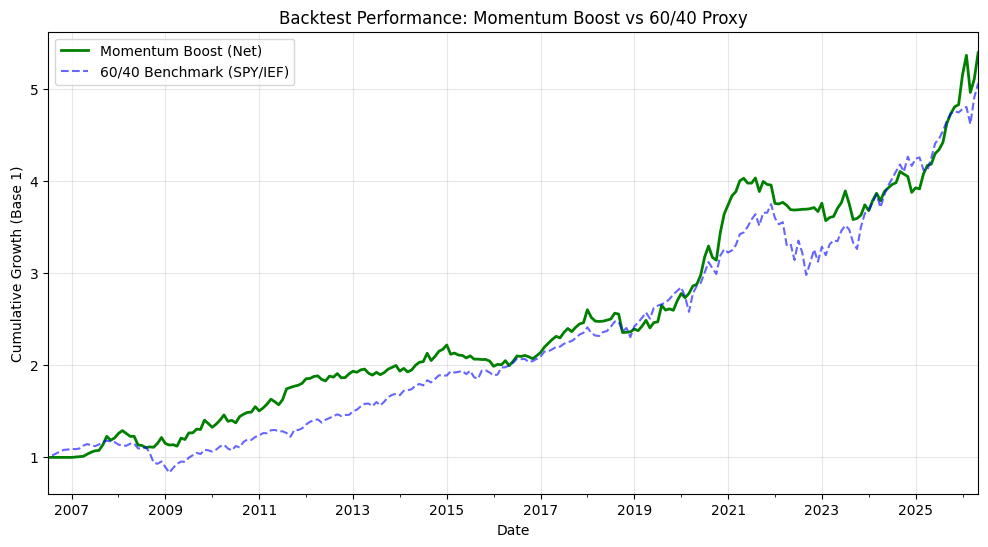

In [11]:
# --- 1. PARAMETERS & BENCHMARK CONSTRUCTION ---
cost_per_trade = 0.0005  # 5 bps cost assumption
first_active_date = weights_turbo[weights_turbo.sum(axis=1) > 0].index[0]

# Calculate Portfolio Returns
gross_returns = (weights_turbo.shift(1) * returns_monthly).sum(axis=1).loc[first_active_date:]
turnover = weights_turbo.diff().abs().sum(axis=1)
net_returns = gross_returns - (turnover.shift(1) * cost_per_trade).fillna(0)

# Construct 60/40 Benchmark (60% SPY, 40% IEF)
benchmark_6040 = (returns_monthly['SPY'] * 0.6 + returns_monthly['IEF'] * 0.4).loc[first_active_date:]

# --- 2. PERFORMANCE METRICS ---
def get_stats(rend):
    years = len(rend) / 12
    cagr = ((1 + ((1 + rend).prod() - 1)) ** (1 / years)) - 1
    vol = rend.std() * np.sqrt(12)
    dd = ((1 + rend).cumprod() / (1 + rend).cumprod().cummax() - 1).min()
    return {"CAGR": f"{cagr*100:.2f}%", "Vol": f"{vol*100:.2f}%", "Sharpe": f"{(cagr/vol):.2f}", "Max DD": f"{dd*100:.1f}%"}

stats_table = pd.DataFrame({
    "Momentum Boost (Net)": get_stats(net_returns),
    "60/40 Benchmark": get_stats(benchmark_6040)
}).T

print("Performance Report: Momentum Boost vs 60/40 Benchmark")
print("="*60)
print(stats_table)
print("="*60)

# --- 3. EQUITY CURVE PLOT ---
plt.figure(figsize=(12, 6))
(1 + net_returns).cumprod().plot(label='Momentum Boost (Net)', color='green', linewidth=2)
(1 + benchmark_6040).cumprod().plot(label='60/40 Benchmark (SPY/IEF)', color='blue', alpha=0.6, linestyle='--')
plt.title("Backtest Performance: Momentum Boost vs 60/40 Proxy")
plt.ylabel("Cumulative Growth (Base 1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
effective_weights = weights_turbo.loc[first_active_date:]
stats = pd.DataFrame(index=effective_weights.columns)

total_months = len(effective_weights)
stats['Months_Invested'] = (effective_weights > 0).sum()
stats['Frequency_%'] = ((stats['Months_Invested'] / total_months) * 100).round(1)
stats['Avg_Weight_%'] = (effective_weights[effective_weights > 0].mean() * 100).round(1)

print(stats.sort_values(by='Months_Invested', ascending=False))

     Months_Invested  Frequency_%  Avg_Weight_%
SHV              164         68.6          31.7
GLD              121         50.6          28.4
VWO              116         48.5          27.1
QQQ              111         46.4          31.8
TIP               91         38.1          15.8
LQD               88         36.8          16.2
TLT               86         36.0          27.3
IWM               77         32.2          30.1
SPY               27         11.3          24.4
IEF               22          9.2          18.0


In [10]:
# Input your total account value in EUR
ACCOUNT_VALUE = 100000

current_portfolio_eur = {
    'QQQ': 0, 'IWM': 0, 'VWO': 0, 'SHV': 0, 'TIP': 0
}

latest_targets = weights_turbo.iloc[-1]
orders = []

for asset in latest_targets.index:
    target_val = latest_targets[asset] * ACCOUNT_VALUE
    current_val = current_portfolio_eur.get(asset, 0)
    diff = target_val - current_val
    
    if abs(diff) > 50:
        action = "BUY" if diff > 0 else "SELL"
        orders.append((action, asset, abs(diff)))

# Display orders
print(f"{'ACTION':<8} | {'ASSET':<8} | {'AMOUNT (EUR)':>12}")
print("-" * 35)
for action, asset, amount in orders:
    print(f"{action:<8} | {asset:<8} | €{amount:>11,.2f}")

ACTION   | ASSET    | AMOUNT (EUR)
-----------------------------------
BUY      | IWM      | €  36,843.60
BUY      | QQQ      | €  40,000.00
BUY      | SHV      | €   8,598.98
BUY      | VWO      | €  14,557.42
